DLモデルの実装が正しいかを確認するための手法として、「意図的な過学習」が上手くいくかを確かめるというやり方がある。これが上手くいけば、実装が正しい可能性が高いだろうと言える。

本稿ではMNISTを使って意図的な過学習を起こしてみる。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.style.use("ggplot")

device = torch.accelerator.current_accelerator(check_available=True)
device

device(type='mps')

In [2]:
ds = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

各数字1枚ずつの学習データを作る

In [3]:
n = 1

ds_train, ds_test = [], []
n_appended = [0 for _ in range(10)]
for img, label in ds:
    if n_appended[label] >= n:
        ds_test.append((img, label))
    else:
        ds_train.append((img, label))
        n_appended[label] += 1

len(ds_train), len(ds_test)

(10, 9990)

In [4]:
dl_train = DataLoader(ds_train, batch_size=1, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=32, shuffle=True)

In [5]:
@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    is_correct = []
    for imgs, labels in dl:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        pred = logits.argmax(dim=1)
        is_correct.extend((pred == labels).tolist())
    return sum(is_correct) / len(is_correct)

def train(model, optimizer, n_epochs=10):
    accs_train, accs_test = [], []
    for epoch in range(n_epochs):
        model.train()
        for imgs, labels in tqdm(dl_train, desc=f"Epoch {epoch+1}/{n_epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
        accs_train.append(evaluate(model, dl_train))
        accs_test.append(evaluate(model, dl_test))
    return accs_train, accs_test

In [6]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)


    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = SimpleNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
accs_train, accs_test = train(model, optimizer, n_epochs=10)

Epoch 10/10: 100%|██████████| 10/10 [00:00<00:00, 903.01it/s]


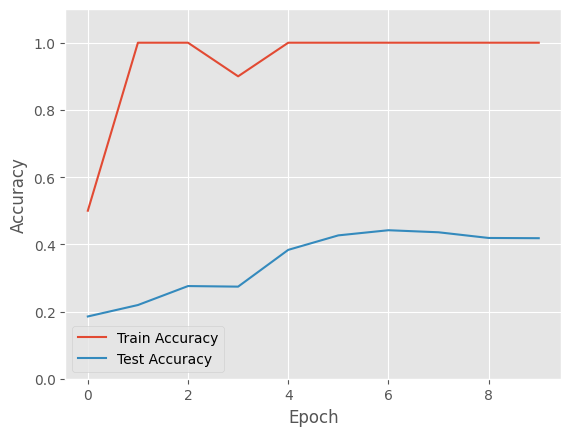

In [8]:
plt.plot(accs_train, label="Train Accuracy")
plt.plot(accs_test, label="Test Accuracy")
plt.ylim(0, 1.1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend();

データ数を増やす（100倍）

In [9]:
n = 100

ds_train, ds_test = [], []
n_appended = [0 for _ in range(10)]
for img, label in ds:
    if n_appended[label] >= n:
        ds_test.append((img, label))
    else:
        ds_train.append((img, label))
        n_appended[label] += 1

len(ds_train), len(ds_test)

(1000, 9000)

Epoch 10/10: 100%|██████████| 1000/1000 [00:01<00:00, 889.10it/s]


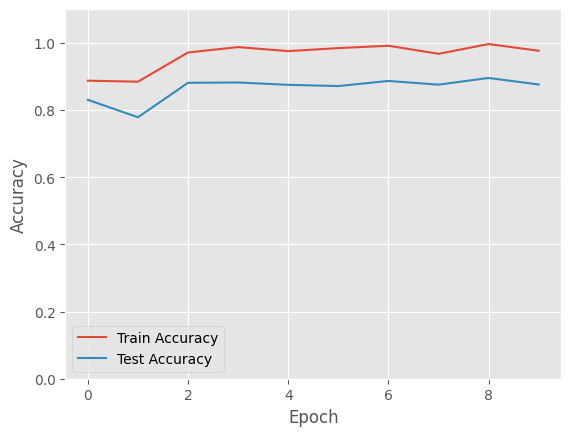

In [10]:
dl_train = DataLoader(ds_train, batch_size=1, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=32, shuffle=True)
model = SimpleNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
accs_train, accs_test = train(model, optimizer, n_epochs=10)

plt.plot(accs_train, label="Train Accuracy")
plt.plot(accs_test, label="Test Accuracy")
plt.ylim(0, 1.1)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend();